# Computer Vision 1: Assignment 3

Task 1

Group Number 43

Marek Drwal

15.12.2025

## setup

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

## defs

In [2]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    plt.show()

In [3]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [4]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [5]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [6]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## imgs

In [7]:
pth = 'coins.jpg'

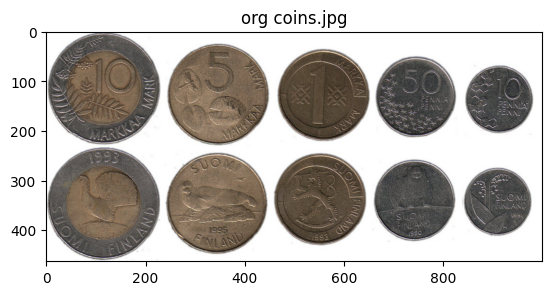

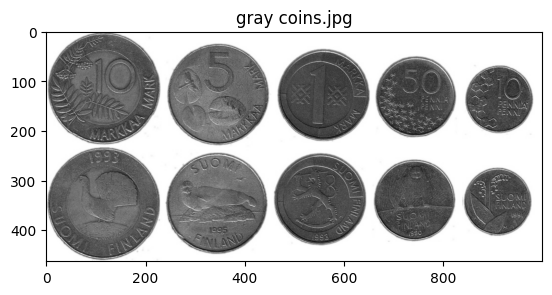

In [8]:
img = load_display_img(pth)

## radii

In [9]:
resolution = 0.12 ## mm/px

In [16]:
rs = [27.25, 24.5, 22.25, 19.7, 16.3]
rs = [r/2/resolution for r in rs]
rs

[113.54166666666667,
 102.08333333333334,
 92.70833333333334,
 82.08333333333333,
 67.91666666666667]

## Canny

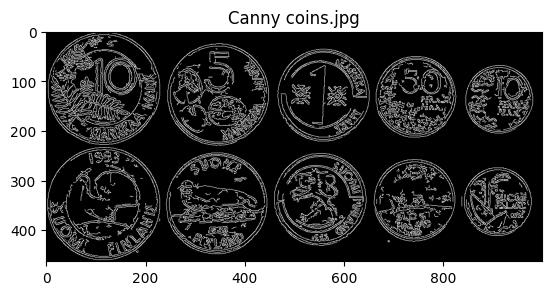

In [13]:
img_edge = ski.feature.canny(img)
show_img(img_edge, pth, 'Canny')

## Hough circle

In [17]:
h_circles = ski.transform.hough_circle(img_edge, rs)

In [19]:
h_circles.shape

(5, 463, 1000)

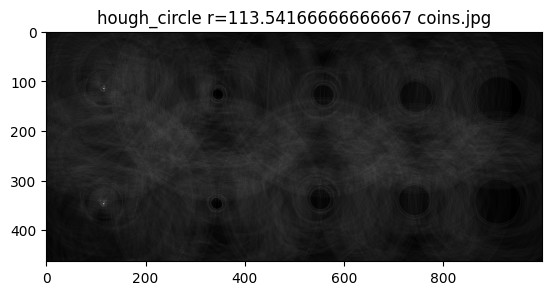

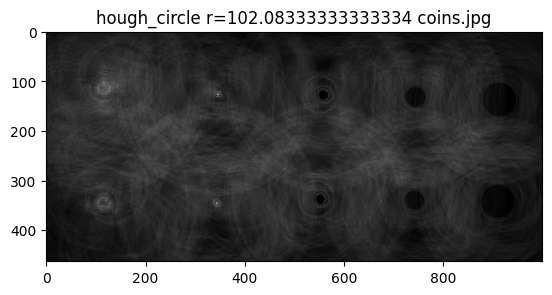

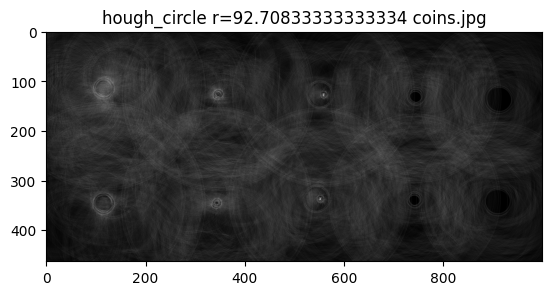

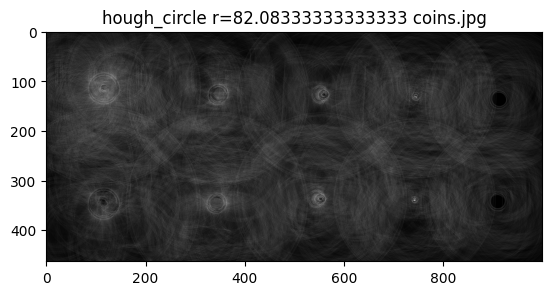

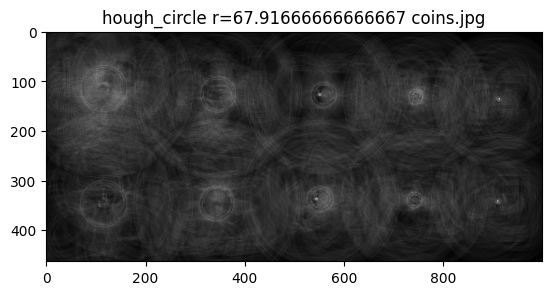

In [21]:
for img, r in zip(h_circles, rs):
    show_img(img, pth, f'hough_circle r={r}')

## Hough circle peaks